In [1]:
import torch
import torch.nn.functional as F 
import matplotlib.pyplot as plt

In [2]:
# read in all words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [8]:
# vocabulary of characters and mappings to/from integers
chars = sorted(list(set("".join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [ ]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words[:3]:
    
    # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix) 
        # print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [140]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([16, 3]), torch.int64, torch.Size([16]), torch.int64)

In [6]:
# create train, dev/val and test splits

def build_dataset(words):
    block_size = 3 # context length: how many characters do we take to predict the next one?
    X, Y = [], []
    for w in words:
        
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix) 
            # print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix] # crop and append
            
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [8]:
C = torch.randn((27, 2))

Based on a paper titled "A neural Probabilistic Language model" by Yoshua Bengio, Réjean Ducharme, Pascal Vincent, and Christian Jauvin, the authors propose a novel approach to language modeling using neural networks. The paper introduces a probabilistic framework that leverages the power of neural networks to capture complex dependencies in natural language data.

In [ ]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [23]:
W1 = torch.randn((6, 100))
b1 = torch.randn((100))

In [25]:
# the shape of a tensor can be manipulated into required format without changing the data
emb.view(32, 6).shape

torch.Size([32, 6])

In [ ]:
# input words are embeddings - and they need to be multiplied with Weights and added to bias. And the hidden layer used is tanh. 
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # -1 is used so that pytorch will change it based on size of X. 
h.shape

torch.Size([32, 100])

In [28]:
# output Neuron
W2 = torch.randn((100, 27)) # we have 26 alphabets + '.' 
b2 = torch.randn((27))

In [29]:
logits = h @ W2 + b2
logits.shape

torch.Size([32, 27])

In [30]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdim= True)
prob.shape

torch.Size([32, 27])

In [33]:
# prob[1, 5] (basically - iterate over 32 rows and then pick the yth column and this Y is the index for "next character") 
prob[torch.arange(32), Y] 

tensor([1.1701e-07, 2.5084e-09, 1.2975e-06, 9.8130e-06, 4.7395e-11, 9.5124e-06,
        1.1502e-06, 6.9300e-07, 1.1435e-06, 2.9388e-10, 3.6196e-06, 6.2218e-09,
        1.1730e-06, 2.1501e-04, 1.8808e-12, 3.9349e-11, 2.1593e-09, 8.0003e-01,
        2.8770e-09, 2.9163e-02, 1.8181e-03, 1.9510e-09, 4.9096e-06, 3.5368e-09,
        7.8683e-08, 1.3664e-01, 3.3726e-05, 9.7744e-08, 9.6913e-05, 2.1203e-11,
        1.3010e-07, 9.8544e-06])

In [34]:
# take the log likelihood loss
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(14.7366)

###                          --------------------Rewritten version--------------------

In [107]:
# rewrite for readablitiy
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [38]:
n_embd = 10 # the number of dimensions for each character embedding
n_hidden = 200 # the number of neurons in the hidden layer

g = torch.Generator().manual_seed(2147483647) 
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * 0.2
b1 = torch.randn((n_hidden), generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn((vocab_size), generator=g) * 0
parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in the model
for p in parameters:
    p.requires_grad = True

11897


In [39]:
# for data this large, it is better to use a batch size of 32.
# So we will take 32 samples at a time and then do the forward pass and backward pass.


# Also, to decide what's the best learning rate, we will do this
# lre = torch.linspace(-3, 0, 1000)
# lrs = 10**lre

In [40]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator= g) # 32 random integers between 0 and 32000    
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X and Y
    
    # forward pass
    emb = C[Xb] 
    embcat = emb.view(emb.shape[0], -1) # flatten the embeddings for each sample in the batch
    hpreact = torch.tanh(embcat @ W1 + b1) # hidden layer pre-activations
    h = torch.tanh(embcat @ W1 + b1) # hidden layer activations
    logits = h @ W2 + b2 # output layer 
    # counts = logits.exp() 
    # prob = counts / counts.sum(1, keepdim= True) 
    # loss = -prob[torch.arange(32), Y].log().mean()
    loss = F.cross_entropy(logits, Yb) # combines the above 3 steps into one function. (softmax + negative log likelihood loss)
    
    # backward pass
    for p in parameters:
        p.grad = None # set the gradients to zero before backward pass
    loss.backward()
    
    # update the parameters using gradient descent
    # lr = lrs[i] 
    lr = 0.01 if i < 100000 else 0.01 # learning rate decay
    for p in parameters:
        p.data += -lr * p.grad # update the parameters using gradient descent
        
    # track stats
    if i % 10000 == 0:
        print(f"{i:7d}/{max_steps:7d}: {loss.item():.4f}")
    lossi.append(loss.log10().item())
# print(loss.item())

      0/ 200000: 3.3135
  10000/ 200000: 2.2317
  20000/ 200000: 2.3488
  30000/ 200000: 2.5524
  40000/ 200000: 1.9776
  50000/ 200000: 2.5183
  60000/ 200000: 2.4216
  70000/ 200000: 2.0875
  80000/ 200000: 2.2269
  90000/ 200000: 2.1372
 100000/ 200000: 1.9769
 110000/ 200000: 2.1971
 120000/ 200000: 2.0112
 130000/ 200000: 2.4508
 140000/ 200000: 2.3213
 150000/ 200000: 2.2109
 160000/ 200000: 1.8588
 170000/ 200000: 1.7665
 180000/ 200000: 2.0286
 190000/ 200000: 1.8253


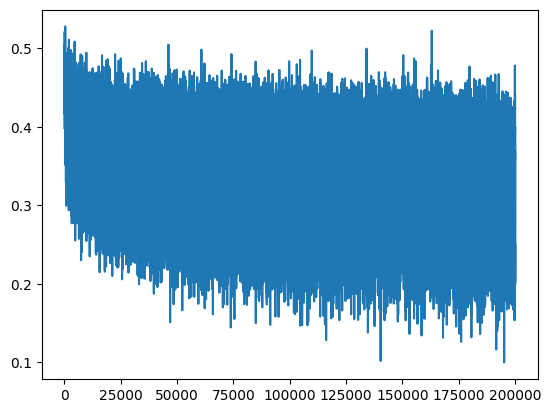

In [41]:
# our initial loss is extremely high than what one expects at initialization. So, we multiply W2, b2 with small number to reduce the loss.
# We can make bias 0 but not the weights because if we make weights 0, then the gradients will also be 0 and the model will not learn anything.
plt.plot(lossi)

In [42]:
@torch.no_grad() # we don't need gradients for this block
def split_loss(split):
    x,y = {
        "train": (Xtr, Ytr),
        "val": (Xdev, Ydev),
        "test": (Xte, Yte),
    }[split]
    emb = C[x] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # flatten the embeddings
    h = torch.tanh(embcat @ W1 + b1) # hidden layer activations
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, y) # compute the loss
    print(f"{split} loss: {loss.item():.4f}")

split_loss("train")
split_loss("val")

train loss: 2.0986
val loss: 2.1346


**loss log** 

**original**: 
train  2.20
val 2.21

**fix softmax confidently wrong**: (basically reducing the initial loss by multiplying W2 and b2 with small numbers)
train 2.16
val 2.17

**fixing tanh saturating during init**: (making sure numbers don't land on -1 and 1 - the flat regions which won't help the gradients to change, making it not learn anything)
train 2.09
val 2.13

We find that train and dev loss are roughly equal and that's because our NN is small. Now, we scale it further. 